# Exploratory Data Analysis
**Dataset:** Daily OHLC prices  
**Goal:** Understand structure, quality, and relationships to inform cleaning & feature engineering.

In [74]:
!pip install seaborn

The value specified in an AutoRun registry key could not be parsed.
DEPRECATION: wfuzz 3.1.0 has a non-standard dependency specifier pyparsing>=2.4*; python_version >= "3.5". pip 24.1 will enforce this behaviour change. A possible replacement is to upgrade to a newer version of wfuzz or contact the author to suggest that they release a version with a conforming dependency specifiers. Discussion can be found at https://github.com/pypa/pip/issues/12063

[notice] A new release of pip is available: 24.0 -> 25.2
[notice] To update, run: C:\Users\Munj Patel\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [75]:
import pandas as pd
import os
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns

In [112]:
ticker_data = yf.Ticker('TSLA').history(period = 'max')
ticker_data = ticker_data[['Open', 'Close', 'High', 'Low']]

print(ticker_data.shape)
print(ticker_data.head())

(3811, 4)
                               Open     Close      High       Low
Date                                                             
2010-06-29 00:00:00-04:00  1.266667  1.592667  1.666667  1.169333
2010-06-30 00:00:00-04:00  1.719333  1.588667  2.028000  1.553333
2010-07-01 00:00:00-04:00  1.666667  1.464000  1.728000  1.351333
2010-07-02 00:00:00-04:00  1.533333  1.280000  1.540000  1.247333
2010-07-06 00:00:00-04:00  1.333333  1.074000  1.333333  1.055333


## 1) Profiling: schema, types, and missingness

In [113]:
# schema
ticker_data.info()

# numeric vs categorical
num_cols = ticker_data.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = ticker_data.select_dtypes(exclude=[np.number]).columns.tolist()
print("\nNumeric columns:", num_cols)
print("Categorical columns:", cat_cols if cat_cols else "None")

# basic stats
display(ticker_data.describe().T.assign(skew=ticker_data.skew(), kurtosis=ticker_data.kurtosis()))

# missing counts
ticker_data.isna().sum()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3811 entries, 2010-06-29 00:00:00-04:00 to 2025-08-21 00:00:00-04:00
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Open    3811 non-null   float64
 1   Close   3811 non-null   float64
 2   High    3811 non-null   float64
 3   Low     3811 non-null   float64
dtypes: float64(4)
memory usage: 148.9 KB

Numeric columns: ['Open', 'Close', 'High', 'Low']
Categorical columns: None


,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
Open,3811.0,91.399139,115.982467,1.076000,12.583666,19.126667,196.551666,475.899994,1.057230,-0.319195
Close,3811.0,91.372616,115.886688,1.053333,12.605667,19.233334,196.885002,479.859985,1.054281,-0.330305
High,3811.0,93.432127,118.594673,1.108667,12.823000,19.578667,200.680000,488.540009,1.057039,-0.317532
Low,3811.0,89.227108,113.118349,0.998667,12.333333,18.773333,191.875000,457.510010,1.053259,-0.339203


Open     0
Close    0
High     0
Low      0
dtype: int64

**Findings (profile):**
- No missing values detected in OHLC (your earlier run showed zeros).
- All columns are numeric; there are no categorical fields in this schema.
- Strong right-skew and very large range suggest **heavy tails**.

## 2) Distributions (histograms & boxplots)

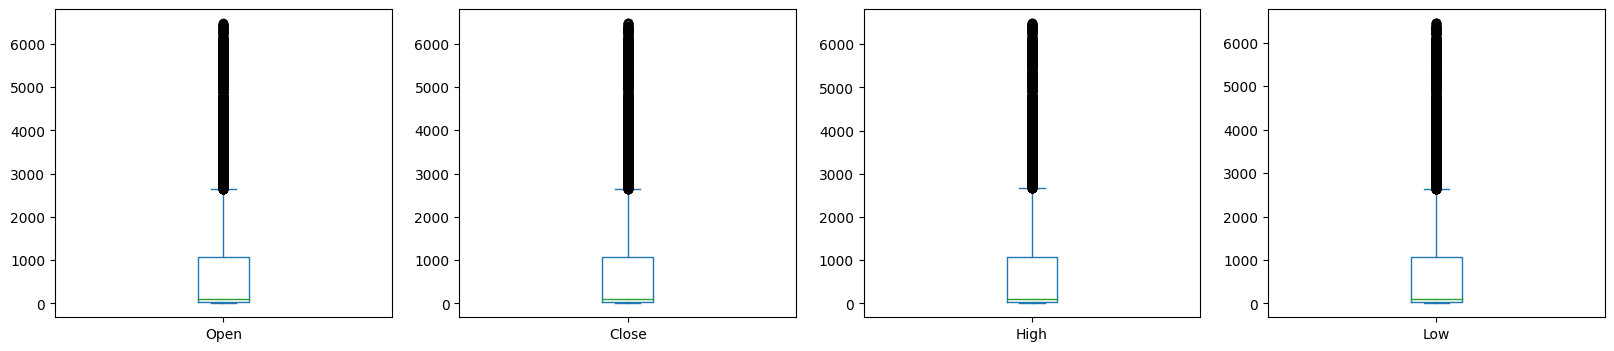

In [102]:
ticker_data.plot(kind = 'box', subplots = True, figsize = (20,4))
plt.show()

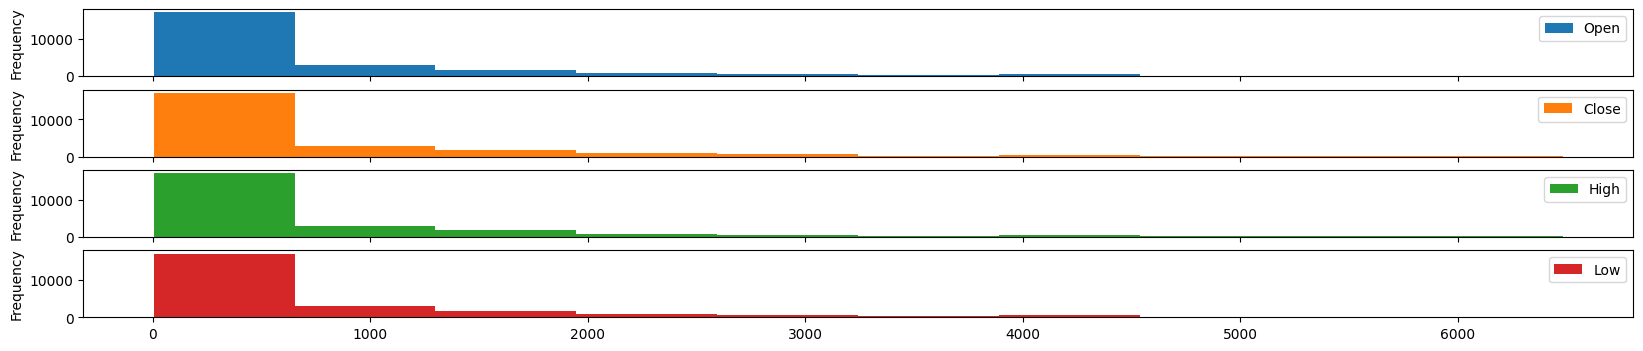

In [108]:
ticker_data.plot(kind = 'hist', subplots = True, figsize = (20,4))
plt.show()

**Notes (distributions):**
- Histograms are **highly right-skewed** because price levels trend upward over decades.
- Boxplots show many “outliers”—these are mostly **true historical extremes** (crashes/spikes), not data errors.

## 3) Bivariate relationships (at least two)

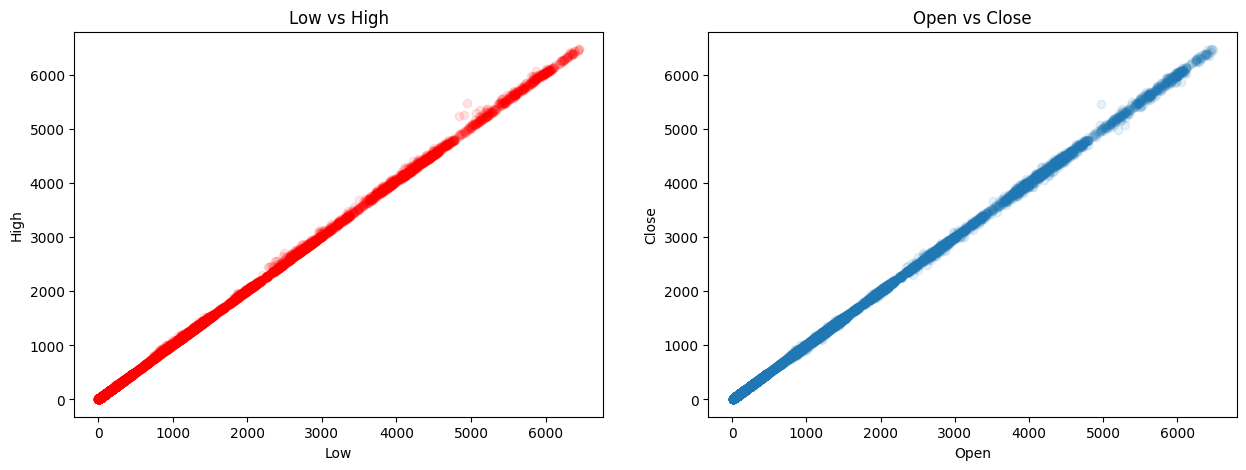

In [94]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(15,5))

ax[0].scatter(ticker_data['Low'], ticker_data['High'], color = 'red', alpha = 0.1)
ax[0].set_xlabel('Low')
ax[0].set_ylabel('High')
ax[0].title.set_text('Low vs High')

ax[1].scatter(ticker_data['Open'], ticker_data['Close'], alpha = 0.1)
ax[1].set_xlabel('Open')
ax[1].set_ylabel('Close')
ax[1].title.set_text('Open vs Close')

# ticker_data.plot(kind = 'scatter', x = 'Low', y = 'High')

**Notes (bivariate):**
- `Low` vs `High` and `Open` vs `Close` are **near-linear** → strong mechanical/temporal coupling within the same day.
- This implies **multicollinearity** across OHLC; downstream models should avoid using all four raw columns together.

## 4) Correlation heatmap

<Axes: >

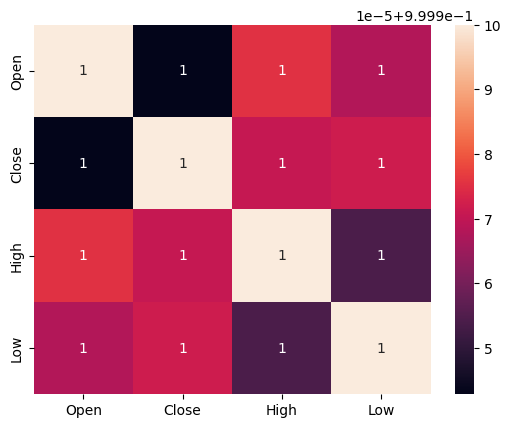

In [109]:
sns.heatmap(ticker_data.corr(), annot = True)

**Interpretation (correlation):**
- Correlations are ~1 among OHLC, confirming redundancy. Prefer engineered features (e.g., range = High–Low, return = Close.pct_change()) over raw OHLC stack.

## 5) Structure, outliers, seasonality checks

,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
ret_close,3810.0,0.002058,0.036542,-0.210628,-0.016538,0.001168,0.019579,0.243951,0.378614,4.934347
range_hl,3810.0,0.042447,0.024493,0.008432,0.026729,0.036837,0.051142,0.298783,2.765146,14.404814


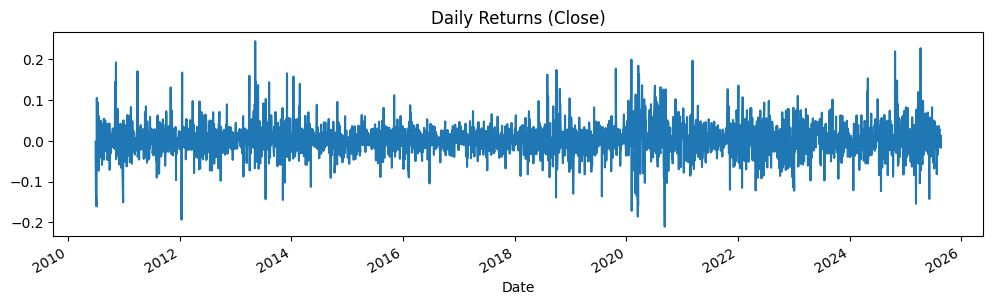

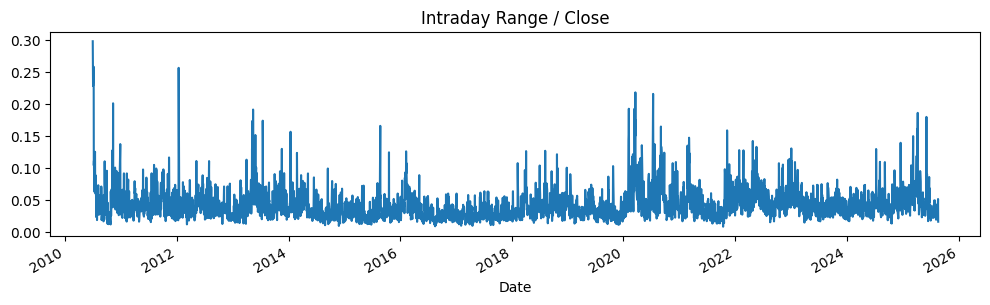

In [115]:
# Simple derived series to reveal structure
out = pd.DataFrame({
    'ret_close': ticker_data['Close'].pct_change(),
    'range_hl': (ticker_data['High'] - ticker_data['Low'])/ticker_data['Close']
}).dropna()

display(out.describe().T.assign(skew=out.skew(), kurtosis=out.kurtosis()))

# Quick plots
out['ret_close'].plot(figsize=(12,3), title='Daily Returns (Close)'); plt.show()
out['range_hl'].plot(figsize=(12,3), title='Intraday Range / Close'); plt.show()

**Observations (structure):**
- Returns center near 0 with **heavy tails** (spikes during crises).
- Intraday range shows volatility clustering—periods of persistently high/low volatility.
- Apparent long-term trend in levels → work in **returns**, not prices, for most modeling.

## Top 3 insights
1. **Near-perfect collinearity** among OHLC → avoid feeding all four into models; engineer compact features (return, range, rolling stats).
2. **Heavy tails & volatility clustering** in returns/range → robust stats (median, winsorization) and volatility features (rolling std/ATR) will be valuable.
3. **No missingness** detected in current export; quality issues are more about **scale/skew/outliers** than gaps.

## Assumptions & risks
- Outliers are assumed to be genuine market moves; trimming/capping could **remove signal** from crisis regimes.
- Using long history blends many market regimes; models may be **non-stationary** if trained on levels—prefer returns and regime-aware validation.
- Correlation conclusions rely on the current schema (daily OHLC). If data vendor changes adjustments (splits/dividends), distributions may shift.

## Implications for next step
- Engineer: `log_return`, `range_hl`, rolling stats (7/14/30-day mean, std), **ATR**, and calendar features (dow, month).
- Normalize or standardize features (on train only). Consider winsorizing top/bottom 1–2% of **returns** (not prices).
- Use **time-series CV** (rolling/expanding windows) and check stability across regimes.